In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic-machine-learning-from-disaster/train.csv
/kaggle/input/titanic-machine-learning-from-disaster/test.csv


**Preprocesamiento de la base de datos** 

In [38]:
import pandas as pd
import numpy as np


In [39]:
path_1 = "/kaggle/input/titanic-machine-learning-from-disaster/train.csv"
path_2 = "/kaggle/input/titanic-machine-learning-from-disaster/test.csv"

train = pd.read_csv(path_1)
test = pd.read_csv(path_2)

In [40]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [41]:
train.shape


(891, 12)

In [42]:
train.isnull().sum()       

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [43]:
train.dropna(inplace=True)

In [44]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [45]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Survived     183 non-null    int64  
 2   Pclass       183 non-null    int64  
 3   Name         183 non-null    object 
 4   Sex          183 non-null    object 
 5   Age          183 non-null    float64
 6   SibSp        183 non-null    int64  
 7   Parch        183 non-null    int64  
 8   Ticket       183 non-null    object 
 9   Fare         183 non-null    float64
 10  Cabin        183 non-null    object 
 11  Embarked     183 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 18.6+ KB


In [46]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [47]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S


In [48]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000
mean,455.366120,0.672131,1.191257,35.674426,0.464481,0.475410,78.682469
std,247.052476,0.470725,0.515187,15.643866,0.644159,0.754617,76.347843
min,2.000000,0.000000,1.000000,0.920000,0.000000,0.000000,0.000000
25%,263.500000,0.000000,1.000000,24.000000,0.000000,0.000000,29.700000
50%,457.000000,1.000000,1.000000,36.000000,0.000000,0.000000,57.000000
75%,676.000000,1.000000,1.000000,47.500000,1.000000,1.000000,90.000000
max,890.000000,1.000000,3.000000,80.000000,3.000000,4.000000,512.329200


In [49]:
ytrain = train['Survived']
train = train.drop(['Name','Ticket','PassengerId','Cabin','Survived'], axis=1)

In [50]:
ytrain

1      1
3      1
6      0
10     1
11     1
      ..
871    1
872    0
879    1
887    1
889    1
Name: Survived, Length: 183, dtype: int64

In [51]:
train.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='object')

In [52]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

encoder_ = OrdinalEncoder()
lista = ["Sex", "Embarked"]
train[lista]= encoder_.fit_transform(train[lista])
imputer_ = SimpleImputer(strategy='median')
train[['Age','Embarked']] = imputer_.fit_transform(train[['Age','Embarked']])

In [53]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    183 non-null    int64  
 1   Sex       183 non-null    float64
 2   Age       183 non-null    float64
 3   SibSp     183 non-null    int64  
 4   Parch     183 non-null    int64  
 5   Fare      183 non-null    float64
 6   Embarked  183 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 11.4 KB


array([[<Axes: title={'center': 'Pclass'}>,
        <Axes: title={'center': 'Sex'}>, <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>,
        <Axes: title={'center': 'Fare'}>],
       [<Axes: title={'center': 'Embarked'}>, <Axes: >, <Axes: >]],
      dtype=object)

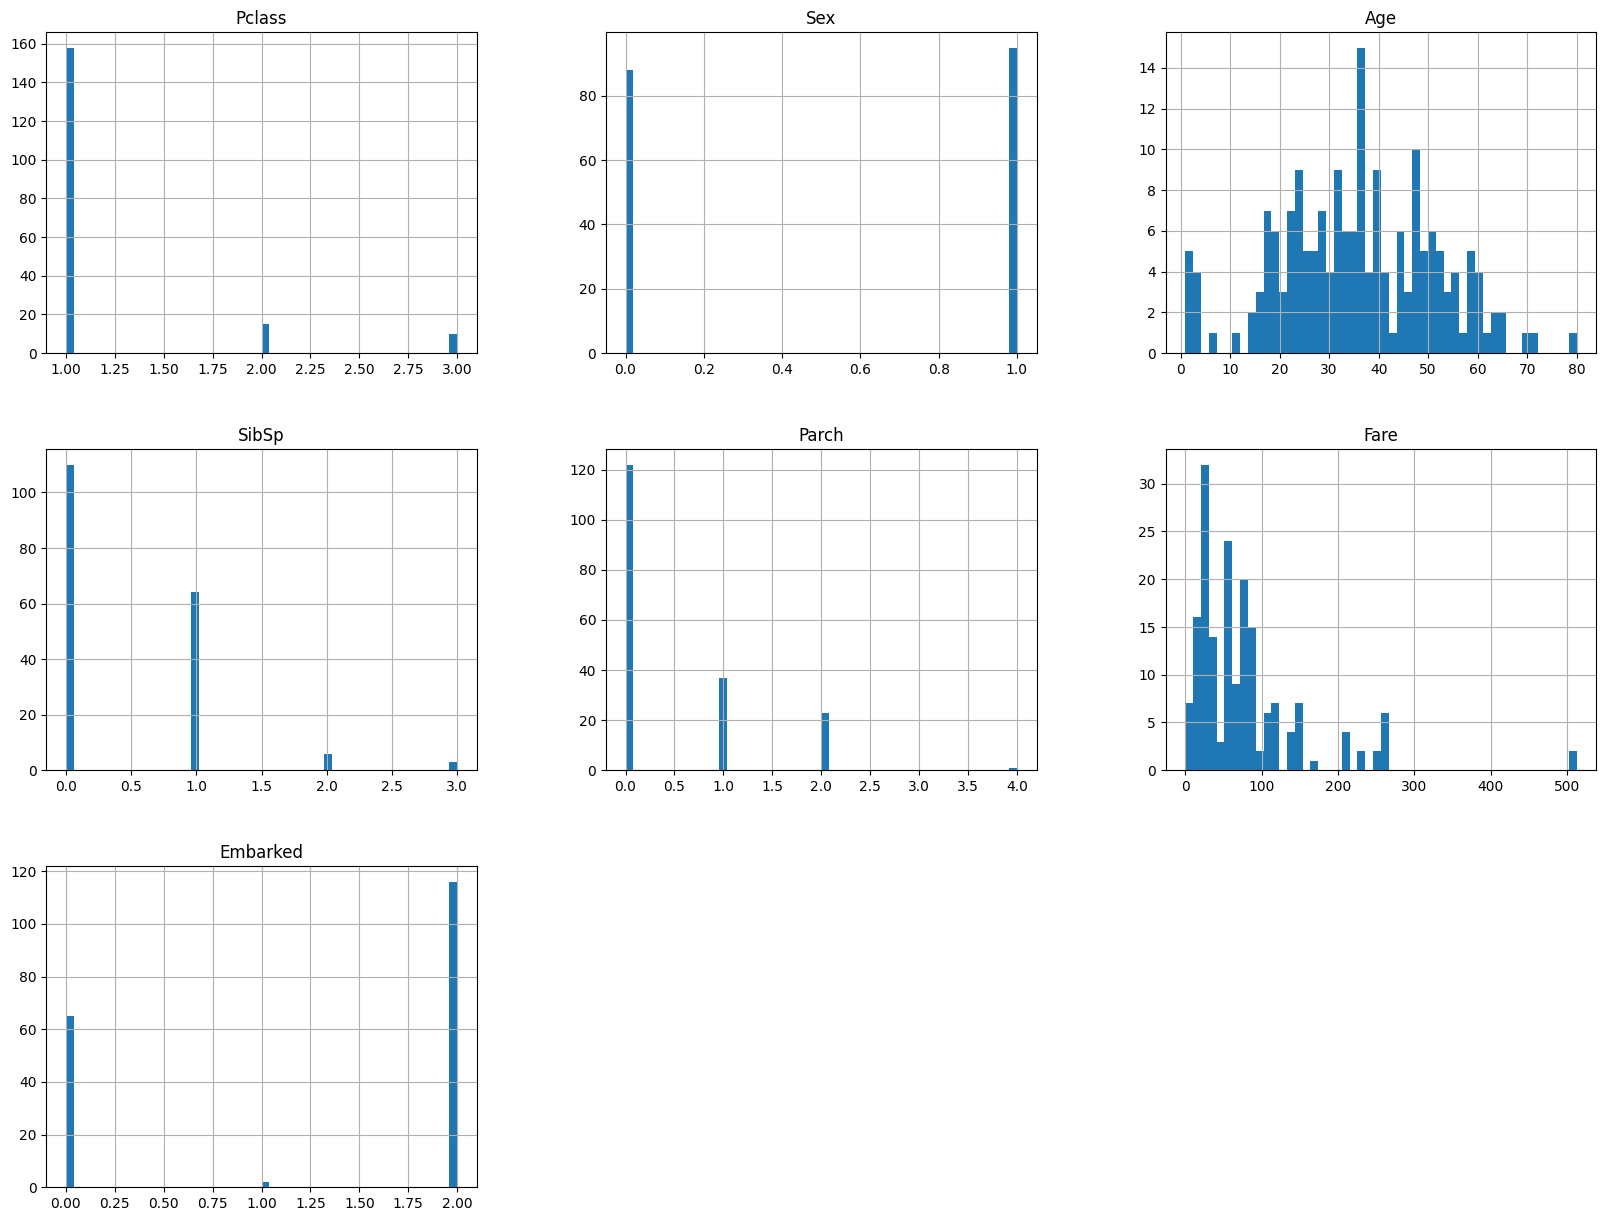

In [54]:
train.hist(bins=50, figsize=(20,15))

**PCA**

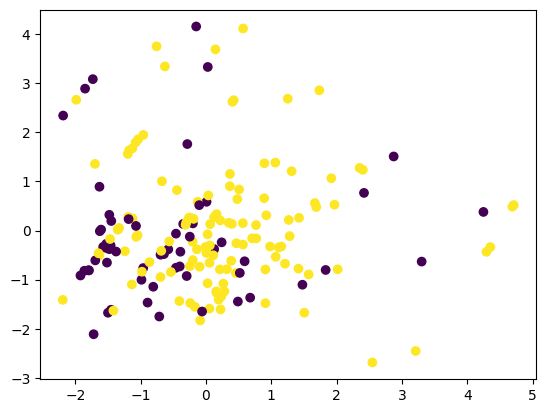

In [55]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

sca_ = StandardScaler()
red_ = PCA(n_components = 2)
ztrain = red_.fit_transform(sca_.fit_transform(train))
ztrain.shape
plt.scatter(ztrain[:,0],ztrain[:,1],c=ytrain)

**UMAP**

In [56]:
from cuml.manifold import UMAP
import time

umap = UMAP(
    n_neighbors=500,     # más pequeño => preserva estructura local
    min_dist=0.2,       # menor => clusters más compactos
    n_components=2,     # proyección 2D
#    metric="euclidean", # métrica por defecto
#    init="spectral",    # inicialización estable
#    random_state=42
)
sca_ = StandardScaler()
z = umap.fit_transform(sca_.fit_transform(train))
z = np.asarray(z)


[2025-10-26 21:58:24.627] [CUML] [info] Building knn graph using brute force


In [57]:
ytrain1 = np.asarray(ytrain)
ytrain1

array([1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1])

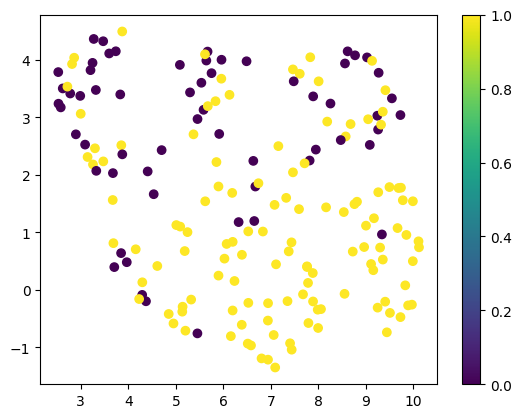

In [58]:
plt.scatter(z[:,0],z[:,1],c=ytrain1)
plt.colorbar()
plt.show()

**Clasificadores**

In [59]:
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
import numpy as np
from scipy.stats import multivariate_normal as mn
import warnings
warnings.filterwarnings("ignore")

#función para muestrear problema biclase desde Gaussianas multivariadas
def my_biclass_gm(mu1,Sigma1,mu2,Sigma2,N1=100,N2=100):
  pdf1 = mn(mu1, Sigma1) # objeto scipy para evaluar o muestrear gaussiana multivariada
  pdf2 = mn(mu2,Sigma2)
  X = np.r_[pdf1.rvs(size=N1),pdf2.rvs(size=N2)] # muestrear de las dos pdfs los datos (NO hacer esto-los datos X los ingresa el usuario)
  y = np.r_[-1.0*np.ones((N1,1)),np.ones((N2,1))] #etiquetas, -1 y +1 para el problema binario
  return X, y

#función para graficar frontera de decisión
def my_plot_biclassifier(model,X,y,levels=15,h = 0.5,score_type="decision_function"): #h:paso en el mesh
    plt.scatter(X[(y==-1).ravel(),0],X[(y==-1).ravel(),1],c='r',marker='o')
    plt.scatter(X[(y==1).ravel(),0],X[(y==1).ravel(),1],c='b',marker='x')
    plt.xlabel('atributo 1')
    plt.ylabel('atributo 2')

    #rangos de análisis
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))#definir rejilla sobre espacio 2D

    # evaluar decision function o predict proba del modelo
    if score_type == "predict_proba":
      if hasattr(model, "predict_proba"):
          Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]#se define clase en columna 1 como target
      else:
        Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    else:
      if hasattr(model, "decision_function"):
          Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])#se define clase en columna 1 como target
      else:
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]


    # graficar resultado en color
    Z = Z.reshape(xx.shape)
    pb = plt.gca().contourf(xx, yy, Z, levels=levels,cmap=plt.cm.RdBu, alpha=0.3)
    cbar_ax = plt.gcf().add_axes([1.01, 0, 0.025, 0.95])
    plt.gcf().colorbar(pb,extend='both', cax=cbar_ax)

    return

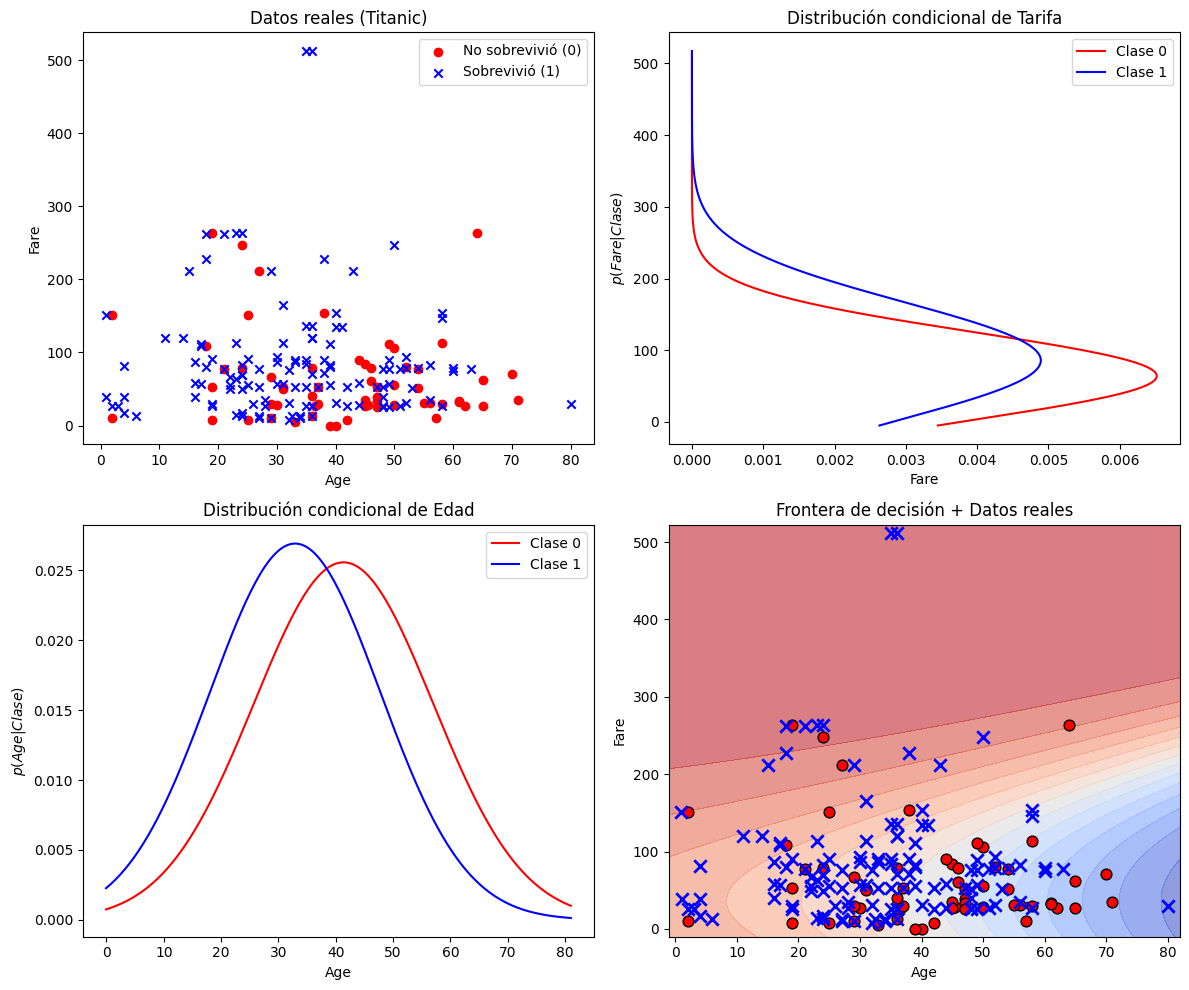

In [60]:
# ==============================================================
#   TITANIC - BAYES INGENUO GAUSSIANO
#   Gráficos estilo original (PDFs + fronteras + datos reales)
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm as mn
from sklearn.naive_bayes import GaussianNB

# 1️⃣ Usar tus datos ya preprocesados
X_full = train.copy()       # tus atributos listos
y_real = ytrain.copy()      # etiquetas reales (0 / 1)

# 2️⃣ Seleccionar variables a visualizar (como "atributo 1" y "atributo 2")
col1, col2 = 'Age', 'Fare'
X = X_full[[col1, col2]].values
y = y_real.values

# 3️⃣ Entrenar el modelo Naive Bayes
cla = GaussianNB()
cla.fit(X, y)
ye = cla.predict(X)

# ==============================================================
#   4️⃣ GRAFICAR PDFs Y DATOS
# ==============================================================

plt.figure(figsize=(12,10))

# --- Subplot 1: Datos originales ---
plt.subplot(221)
plt.scatter(X[y==0,0], X[y==0,1], c='r', marker='o', label='No sobrevivió (0)')
plt.scatter(X[y==1,0], X[y==1,1], c='b', marker='x', label='Sobrevivió (1)')
plt.xlabel(col1)
plt.ylabel(col2)
plt.title('Datos reales (Titanic)')
plt.legend()

# --- PDFs marginales ---
var_ = cla.var_  # varianzas calculadas (n_clases x n_atributos)
mu_ = cla.theta_ # medias calculadas (n_clases x n_atributos)

mn11 = mn(mu_[0,0], np.sqrt(var_[0,0]))  # p(x1|clase0)
mn21 = mn(mu_[1,0], np.sqrt(var_[1,0]))  # p(x1|clase1)
mn12 = mn(mu_[0,1], np.sqrt(var_[0,1]))  # p(x2|clase0)
mn22 = mn(mu_[1,1], np.sqrt(var_[1,1]))  # p(x2|clase1)

xx = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)
yy = np.linspace(X[:,1].min()-5, X[:,1].max()+5, 200)

pdf11 = mn11.pdf(xx)
pdf21 = mn21.pdf(xx)
pdf12 = mn12.pdf(yy)
pdf22 = mn22.pdf(yy)

# --- Subplot 2: PDF de x2 (Fare) ---
plt.subplot(222)
plt.plot(pdf12, yy, 'r', label='Clase 0')
plt.plot(pdf22, yy, 'b', label='Clase 1')
plt.ylabel(f'$p({col2}|Clase)$')
plt.xlabel(col2)
plt.title('Distribución condicional de Tarifa')
plt.legend()

# --- Subplot 3: PDF de x1 (Age) ---
plt.subplot(223)
plt.plot(xx, pdf11, 'r', label='Clase 0')
plt.plot(xx, pdf21, 'b', label='Clase 1')
plt.xlabel(col1)
plt.ylabel(f'$p({col1}|Clase)$')
plt.title('Distribución condicional de Edad')
plt.legend()

plt.subplots_adjust(wspace=0.4, hspace=0.4)

# ==============================================================
#   5️⃣ FRONTERA DE DECISIÓN CON DATOS REALES
# ==============================================================

plt.subplot(224)

# Rango para la malla
x_min, x_max = X[:,0].min()-2, X[:,0].max()+2
y_min, y_max = X[:,1].min()-10, X[:,1].max()+10
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Evaluar probabilidad del modelo
Z = cla.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Fondo de decisión
plt.contourf(xx, yy, Z, levels=15, cmap='coolwarm', alpha=0.6)

# Datos reales encima
plt.scatter(X[y==0,0], X[y==0,1], c='r', marker='o', edgecolor='k', s=60)
plt.scatter(X[y==1,0], X[y==1,1], c='b', marker='x', s=80, linewidths=2)

plt.xlabel(col1)
plt.ylabel(col2)
plt.title('Frontera de decisión + Datos reales')
plt.tight_layout()
plt.show()


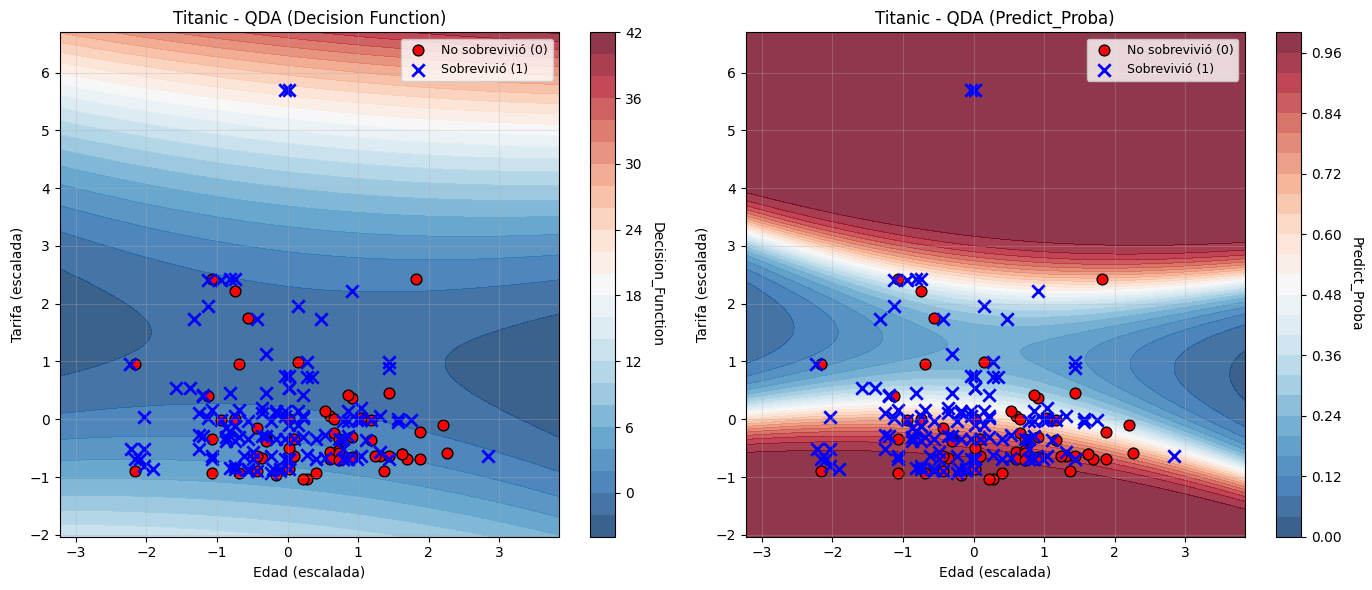

In [61]:
# ==============================================================
# TITANIC - QDA (Decision Function + Predict Proba) - Escalado
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

# 1️⃣ Escalar todas las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(train.copy())
y_real = ytrain.copy().values

# 2️⃣ Entrenar modelo QDA
cla = QuadraticDiscriminantAnalysis(store_covariance=True)
cla.fit(X_scaled, y_real)

# 3️⃣ Variables a visualizar
col1, col2 = 'Age', 'Fare'
ix1 = list(train.columns).index(col1)
ix2 = list(train.columns).index(col2)
X_vis = X_scaled[:, [ix1, ix2]]

# 4️⃣ Crear malla de puntos (Age vs Fare escaladas)
x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# 5️⃣ Fijar las otras variables en 0 (su media escalada)
means = np.zeros(X_scaled.shape[1]-2)
X_grid = np.tile(means, (xx.ravel().shape[0], 1))
X_grid = np.insert(X_grid, 0, xx.ravel(), axis=1)
X_grid = np.insert(X_grid, 1, yy.ravel(), axis=1)

# ==============================================================
#   6️⃣ Calcular Decision Function y Predict_Proba
# ==============================================================

# Decision Function (si no existe, usar predict_proba)
try:
    Z_dec = cla.decision_function(X_grid)
except:
    Z_dec = cla.predict_proba(X_grid)[:,1]
Z_dec = Z_dec.reshape(xx.shape)

# Predict_Proba
Z_prob = cla.predict_proba(X_grid)[:,1]
Z_prob = Z_prob.reshape(xx.shape)

# ==============================================================
#   7️⃣ Graficar ambas (lado a lado)
# ==============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1: Decision Function ---
contour1 = axes[0].contourf(xx, yy, Z_dec, levels=25, cmap='RdBu_r', alpha=0.8)
cbar1 = fig.colorbar(contour1, ax=axes[0])
cbar1.set_label('Decision_Function', rotation=270, labelpad=15)

axes[0].scatter(X_vis[y_real==0,0], X_vis[y_real==0,1],
                c='red', marker='o', edgecolor='k', s=60, label='No sobrevivió (0)')
axes[0].scatter(X_vis[y_real==1,0], X_vis[y_real==1,1],
                c='blue', marker='x', s=80, linewidths=2, label='Sobrevivió (1)')

axes[0].set_xlabel('Edad (escalada)')
axes[0].set_ylabel('Tarifa (escalada)')
axes[0].set_title('Titanic - QDA (Decision Function)')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(alpha=0.3)

# --- Subplot 2: Predict_Proba ---
contour2 = axes[1].contourf(xx, yy, Z_prob, levels=25, cmap='RdBu_r', alpha=0.8)
cbar2 = fig.colorbar(contour2, ax=axes[1])
cbar2.set_label('Predict_Proba', rotation=270, labelpad=15)

axes[1].scatter(X_vis[y_real==0,0], X_vis[y_real==0,1],
                c='red', marker='o', edgecolor='k', s=60, label='No sobrevivió (0)')
axes[1].scatter(X_vis[y_real==1,0], X_vis[y_real==1,1],
                c='blue', marker='x', s=80, linewidths=2, label='Sobrevivió (1)')

axes[1].set_xlabel('Edad (escalada)')
axes[1].set_ylabel('Tarifa (escalada)')
axes[1].set_title('Titanic - QDA (Predict_Proba)')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


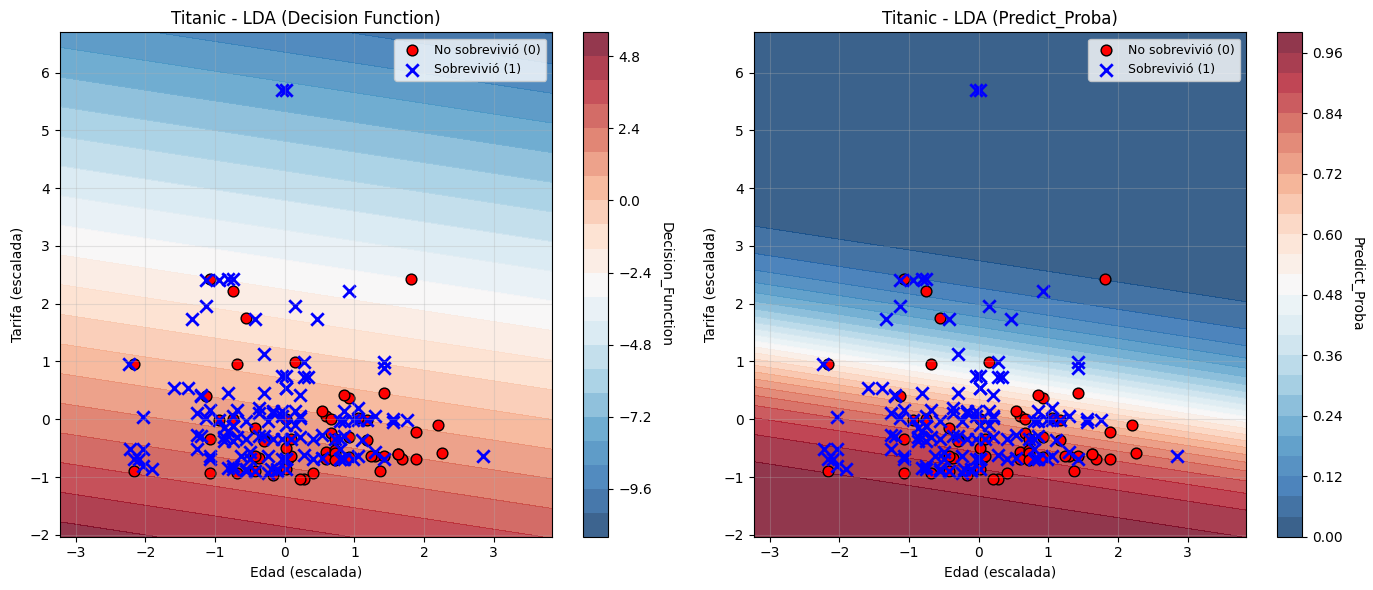

In [62]:
# ==============================================================
# TITANIC - LDA (Decision Function + Predict Proba) - Escalado
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

# 1️⃣ Escalar todas las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(train.copy())
y_real = ytrain.copy().values

# 2️⃣ Entrenar modelo LDA
cla = LinearDiscriminantAnalysis(store_covariance=True)
cla.fit(X_scaled, y_real)

# 3️⃣ Variables a visualizar
col1, col2 = 'Age', 'Fare'
ix1 = list(train.columns).index(col1)
ix2 = list(train.columns).index(col2)
X_vis = X_scaled[:, [ix1, ix2]]

# 4️⃣ Crear malla de puntos (Age vs Fare escaladas)
x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# 5️⃣ Fijar las otras variables en 0 (su media escalada)
means = np.zeros(X_scaled.shape[1]-2)
X_grid = np.tile(means, (xx.ravel().shape[0], 1))
X_grid = np.insert(X_grid, 0, xx.ravel(), axis=1)
X_grid = np.insert(X_grid, 1, yy.ravel(), axis=1)

# ==============================================================
#   6️⃣ Calcular Decision Function y Predict_Proba
# ==============================================================

# Decision Function (si no existe, usar predict_proba)
try:
    Z_dec = cla.decision_function(X_grid)
except:
    Z_dec = cla.predict_proba(X_grid)[:,1]
Z_dec = Z_dec.reshape(xx.shape)

# Predict_Proba
Z_prob = cla.predict_proba(X_grid)[:,1]
Z_prob = Z_prob.reshape(xx.shape)

# ==============================================================
#   7️⃣ Graficar ambas (lado a lado)
# ==============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1: Decision Function ---
contour1 = axes[0].contourf(xx, yy, Z_dec, levels=25, cmap='RdBu_r', alpha=0.8)
cbar1 = fig.colorbar(contour1, ax=axes[0])
cbar1.set_label('Decision_Function', rotation=270, labelpad=15)

axes[0].scatter(X_vis[y_real==0,0], X_vis[y_real==0,1],
                c='red', marker='o', edgecolor='k', s=60, label='No sobrevivió (0)')
axes[0].scatter(X_vis[y_real==1,0], X_vis[y_real==1,1],
                c='blue', marker='x', s=80, linewidths=2, label='Sobrevivió (1)')

axes[0].set_xlabel('Edad (escalada)')
axes[0].set_ylabel('Tarifa (escalada)')
axes[0].set_title('Titanic - LDA (Decision Function)')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(alpha=0.3)

# --- Subplot 2: Predict_Proba ---
contour2 = axes[1].contourf(xx, yy, Z_prob, levels=25, cmap='RdBu_r', alpha=0.8)
cbar2 = fig.colorbar(contour2, ax=axes[1])
cbar2.set_label('Predict_Proba', rotation=270, labelpad=15)

axes[1].scatter(X_vis[y_real==0,0], X_vis[y_real==0,1],
                c='red', marker='o', edgecolor='k', s=60, label='No sobrevivió (0)')
axes[1].scatter(X_vis[y_real==1,0], X_vis[y_real==1,1],
                c='blue', marker='x', s=80, linewidths=2, label='Sobrevivió (1)')

axes[1].set_xlabel('Edad (escalada)')
axes[1].set_ylabel('Tarifa (escalada)')
axes[1].set_title('Titanic - LDA (Predict_Proba)')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


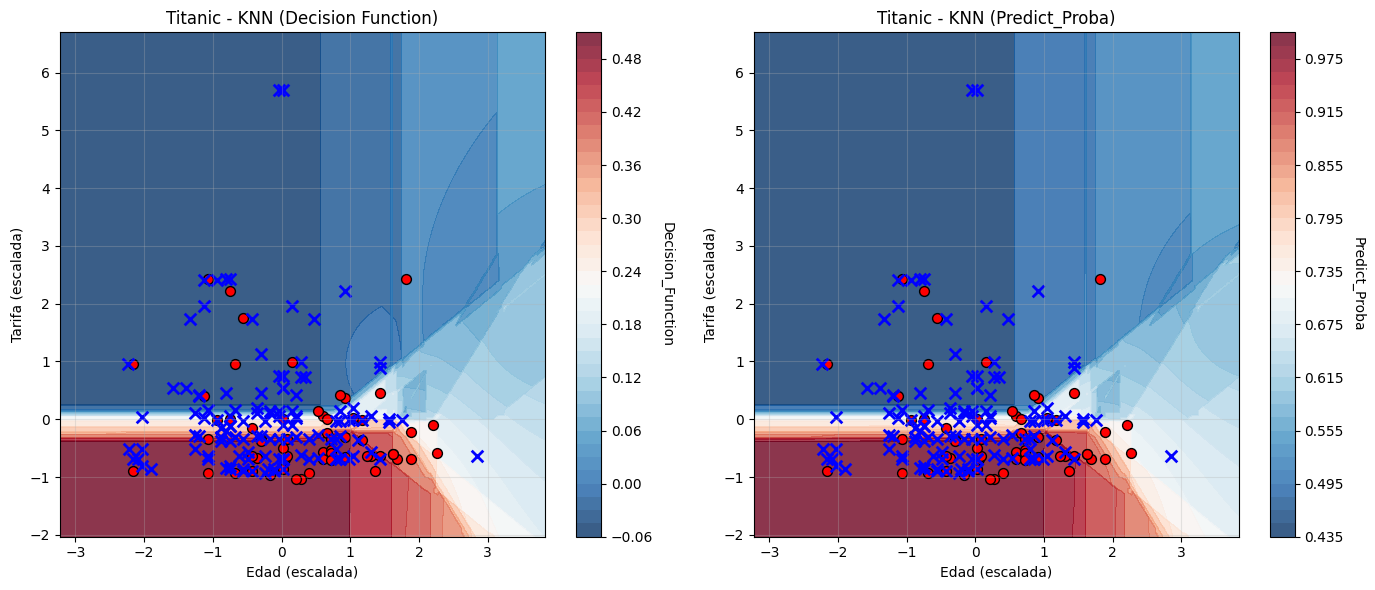

In [63]:
# ==============================================================
# TITANIC - KNN (versión suavizada)
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1️⃣ Escalar todas las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(train.copy())
y_real = ytrain.copy().values

# 2️⃣ Entrenar modelo más suave
cla = KNeighborsClassifier(n_neighbors=25, weights='distance')
cla.fit(X_scaled, y_real)

# 3️⃣ Variables a visualizar
col1, col2 = 'Age', 'Fare'
ix1 = list(train.columns).index(col1)
ix2 = list(train.columns).index(col2)
X_vis = X_scaled[:, [ix1, ix2]]

# 4️⃣ Crear malla más fina
x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 600),
                     np.linspace(y_min, y_max, 600))

# 5️⃣ Fijar las otras variables en 0
means = np.zeros(X_scaled.shape[1]-2)
X_grid = np.tile(means, (xx.ravel().shape[0], 1))
X_grid = np.insert(X_grid, 0, xx.ravel(), axis=1)
X_grid = np.insert(X_grid, 1, yy.ravel(), axis=1)

# 6️⃣ Calcular probabilidades
Z_prob = cla.predict_proba(X_grid)[:,1]
Z_prob = Z_prob.reshape(xx.shape)
Z_dec = Z_prob - 0.5

# 7️⃣ Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Decision Function
contour1 = axes[0].contourf(xx, yy, Z_dec, levels=40, cmap='RdBu_r', alpha=0.8)
fig.colorbar(contour1, ax=axes[0]).set_label('Decision_Function', rotation=270, labelpad=15)
axes[0].scatter(X_vis[y_real==0,0], X_vis[y_real==0,1], c='red', marker='o', edgecolor='k', s=50)
axes[0].scatter(X_vis[y_real==1,0], X_vis[y_real==1,1], c='blue', marker='x', s=70, linewidths=2)
axes[0].set_xlabel('Edad (escalada)')
axes[0].set_ylabel('Tarifa (escalada)')
axes[0].set_title('Titanic - KNN (Decision Function)')
axes[0].grid(alpha=0.3)

# Predict Proba
contour2 = axes[1].contourf(xx, yy, Z_prob, levels=40, cmap='RdBu_r', alpha=0.8)
fig.colorbar(contour2, ax=axes[1]).set_label('Predict_Proba', rotation=270, labelpad=15)
axes[1].scatter(X_vis[y_real==0,0], X_vis[y_real==0,1], c='red', marker='o', edgecolor='k', s=50)
axes[1].scatter(X_vis[y_real==1,0], X_vis[y_real==1,1], c='blue', marker='x', s=70, linewidths=2)
axes[1].set_xlabel('Edad (escalada)')
axes[1].set_ylabel('Tarifa (escalada)')
axes[1].set_title('Titanic - KNN (Predict_Proba)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


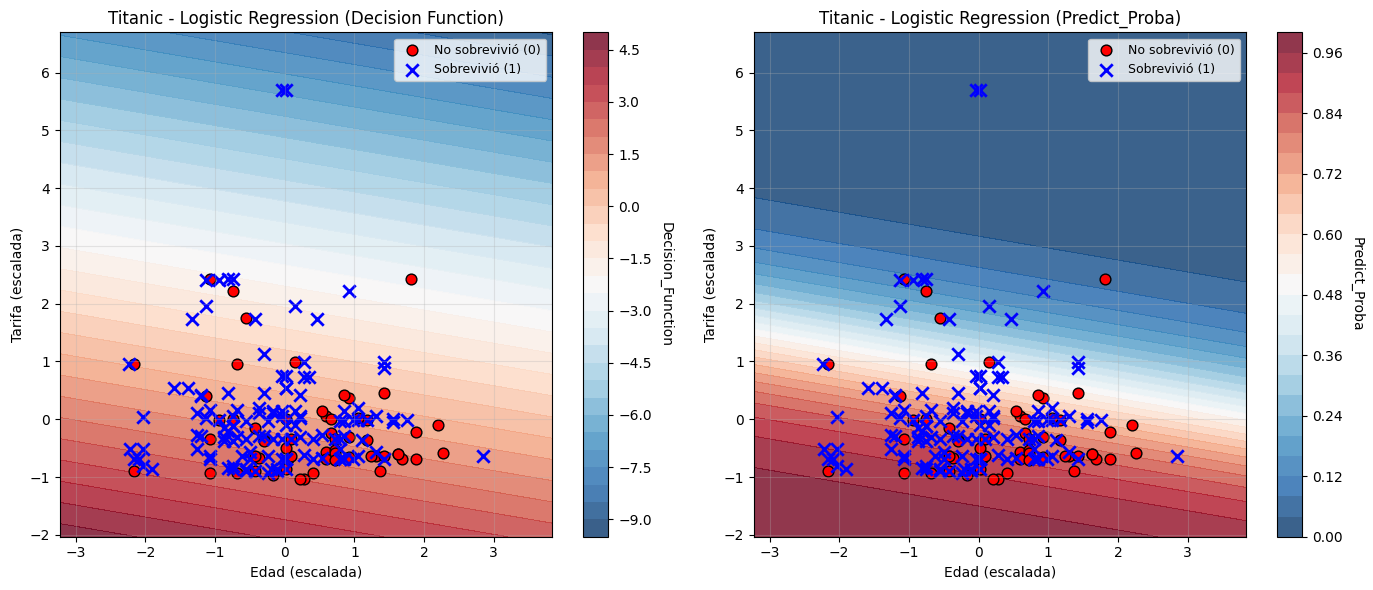

In [64]:
# ==============================================================
# TITANIC - Logistic Regression (Decision Function + Predict Proba)
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1️⃣ Escalar todas las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(train.copy())
y_real = ytrain.copy().values

# 2️⃣ Entrenar modelo de Regresión Logística
cla = LogisticRegression(max_iter=1000)
cla.fit(X_scaled, y_real)

# 3️⃣ Variables a visualizar
col1, col2 = 'Age', 'Fare'
ix1 = list(train.columns).index(col1)
ix2 = list(train.columns).index(col2)
X_vis = X_scaled[:, [ix1, ix2]]

# 4️⃣ Crear malla de puntos (Age vs Fare escaladas)
x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

# 5️⃣ Fijar las otras variables en 0 (media escalada)
means = np.zeros(X_scaled.shape[1]-2)
X_grid = np.tile(means, (xx.ravel().shape[0], 1))
X_grid = np.insert(X_grid, 0, xx.ravel(), axis=1)
X_grid = np.insert(X_grid, 1, yy.ravel(), axis=1)

# ==============================================================
#   6️⃣ Calcular Decision Function y Predict_Proba
# ==============================================================

Z_dec = cla.decision_function(X_grid).reshape(xx.shape)
Z_prob = cla.predict_proba(X_grid)[:,1].reshape(xx.shape)

# ==============================================================
#   7️⃣ Graficar ambas (lado a lado)
# ==============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1: Decision Function ---
contour1 = axes[0].contourf(xx, yy, Z_dec, levels=30, cmap='RdBu_r', alpha=0.8)
cbar1 = fig.colorbar(contour1, ax=axes[0])
cbar1.set_label('Decision_Function', rotation=270, labelpad=15)

axes[0].scatter(X_vis[y_real==0,0], X_vis[y_real==0,1],
                c='red', marker='o', edgecolor='k', s=60, label='No sobrevivió (0)')
axes[0].scatter(X_vis[y_real==1,0], X_vis[y_real==1,1],
                c='blue', marker='x', s=80, linewidths=2, label='Sobrevivió (1)')

axes[0].set_xlabel('Edad (escalada)')
axes[0].set_ylabel('Tarifa (escalada)')
axes[0].set_title('Titanic - Logistic Regression (Decision Function)')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(alpha=0.3)

# --- Subplot 2: Predict_Proba ---
contour2 = axes[1].contourf(xx, yy, Z_prob, levels=30, cmap='RdBu_r', alpha=0.8)
cbar2 = fig.colorbar(contour2, ax=axes[1])
cbar2.set_label('Predict_Proba', rotation=270, labelpad=15)

axes[1].scatter(X_vis[y_real==0,0], X_vis[y_real==0,1],
                c='red', marker='o', edgecolor='k', s=60, label='No sobrevivió (0)')
axes[1].scatter(X_vis[y_real==1,0], X_vis[y_real==1,1],
                c='blue', marker='x', s=80, linewidths=2, label='Sobrevivió (1)')

axes[1].set_xlabel('Edad (escalada)')
axes[1].set_ylabel('Tarifa (escalada)')
axes[1].set_title('Titanic - Logistic Regression (Predict_Proba)')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Clasificación multiclase**

In [65]:
#librerias a importar
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc
from itertools import cycle

import warnings
warnings.filterwarnings("ignore")

#crear carpeta resultados
try:
  os.mkdir('results')
except:
  print("Carpeta results ya existe")

#%%  guardar figuras
def save_fig(path_img,fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(path_img, fig_id + "." + fig_extension)
    print("Guardando...", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
    files.download(path)

import seaborn as sns

#curvas roc multiclase
def roc_auc_mc(roc_auc,fpr,tpr,n_classes,title,path_img):
    lw = 2
    # Falsos positivos
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    # roc
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i]) #interpolar para suavizar
    # promediado sobre numero de clases
    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # graficar
    plt.figure(figsize=(6,6))
    plt.plot(fpr["micro"], tpr["micro"],
             label='micro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)

    plt.plot(fpr["macro"], tpr["macro"],
             label='macro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc["macro"]),
             color='navy', linestyle=':', linewidth=4)

    #colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
    colors = sns.color_palette(None, n_classes)
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=lw,
                 label='AUC_class_{0} (area = {1:0.2f})'
                 ''.format(i, roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="best")#,bbox_to_anchor=(1.4, 0.75))
    plt.show()


#matriz confusión = #[[TN FP][FN TP]]
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') #clasificador aleatorio
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)


# ROC curve and ROC
def roc_multiclass(ytrue,yscore):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    n_classes = ytrue.shape[1]
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(ytrue[:, i], yscore[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Calcular micro-average ROC curve y ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(ytrue.ravel(), yscore.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    return roc_auc, fpr, tpr, n_classes

def plot_confusion_matrix(y_true, y_pred, classes,
                          title=None,
                          cmap=plt.cm.Blues):
    """
    gráfica la matriz de confusión con y sin normalización
    """
    if not title:
        title = 'Matriz de confusión'

    # calcular matriz de confusión
    cm = 100*confusion_matrix(y_true, y_pred,normalize="true")
    # se identifican las etiquetas en los datos
    classes = classes[unique_labels(y_true, y_pred)]

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # mostrar ticks
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='Etiqueta original',
           xlabel='Predicción')

    # Rotar ticks
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # textos.
    fmt = '.1f'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

Carpeta results ya existe


In [66]:
# Hold-out 70/30 con estratificación por la clase
Xtrain, Xtest, ytrain_split, ytest = train_test_split(
    train, ytrain,
    test_size=0.30,
    random_state=123,
    stratify=ytrain  # mantiene proporción de 0/1 en ambos sets
)

In [67]:
# %% Escoger modelo por GridSearchCV utilizando pipeline (Titanic)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib, os

# (opcional) sanity check
assert len(Xtrain) == len(ytrain_split)

# --- Pipelines ---
# Nota:
# - KNN se beneficia del escalado -> MinMaxScaler
# - RandomForest NO requiere escalado -> 'passthrough'
steps = [
    [('nor', MinMaxScaler()),
     ('cla', LogisticRegression(max_iter=200, random_state=123))],          # 1: LogReg
    [('nor', MinMaxScaler()),
     ('cla', SGDClassifier(loss='log_loss', random_state=123))],            # 2: SGD (log para AUC/ROC)
    [('nor', MinMaxScaler()),
     ('cla', SVC(kernel='rbf', probability=True, random_state=123))],       # 3: SVC rbf con probas
    [('nor', MinMaxScaler()),
     ('cla', KNeighborsClassifier())],                                      # 4: KNN
    [('nor', 'passthrough'),
     ('cla', RandomForestClassifier(random_state=123))]                     # 5: RandomForest
]

# --- Parrillas (en el MISMO orden que steps) ---
parameters = [
    {   # 1) LogisticRegression
        'cla__C': [1e-3, 1e-2, 1e-1, 1, 10, 1e2, 1e3],
        'cla__penalty': ['l2'],
        'cla__class_weight': [None, 'balanced'],
        'cla__solver': ['lbfgs']
    },
    {   # 2) SGDClassifier (logístico)
        'cla__alpha': [1e-4, 1e-3, 1e-2],
        'cla__penalty': ['l2', 'elasticnet']
    },
    {   # 3) SVC rbf
        'cla__C': [0.1, 1, 10, 100],
        'cla__gamma': ['scale', 0.01, 0.1]
    },
    {   # 4) KNN
        'cla__n_neighbors': [3, 5, 7, 11],
        'cla__weights': ['uniform', 'distance'],
        'cla__p': [1, 2]  # 1=Manhattan, 2=Euclídea
    },
    {   # 5) RandomForest
        'cla__n_estimators': [200, 500],
        'cla__max_depth': [None, 5, 10, 20],
        'cla__min_samples_split': [2, 5, 10],
        'cla__max_features': ['sqrt', 'log2', 0.5],
        'cla__class_weight': [None, 'balanced']
    }
]

label_models = [
    'MinMax_Logistic',
    'MinMax_SGD',
    'MinMax_SVCrbf',
    'MinMax_KNN',
    'RF'
]

models = []
os.makedirs('results', exist_ok=True)
filename = 'results/titanic_models'  # <- usa este mismo en el .load()

for i in range(len(steps)):  # recorrer modelos según lista pipeline
    print('modelo %d/%d -> %s' % (i+1, len(steps), label_models[i]))
    grid_search = GridSearchCV(
        Pipeline(steps[i]),
        parameters[i],
        n_jobs=-1,
        cv=5,
        scoring='roc_auc',   # si prefieres AUC: scoring='roc_auc'
        refit=True,
        verbose=10
    )
    grid_search.fit(Xtrain, ytrain_split)
    models.append(grid_search)
    joblib.dump(models, filename + ".pkl")



modelo 1/5 -> MinMax_Logistic
Fitting 5 folds for each of 14 candidates, totalling 70 fits

[CV 4/5; 124/144] END cla__class_weight=balanced, cla__max_depth=10, cla__max_features=0.5, cla__min_samples_split=5, cla__n_estimators=500;, score=0.840 total time=   1.1s
[CV 3/5; 125/144] START cla__class_weight=balanced, cla__max_depth=10, cla__max_features=0.5, cla__min_samples_split=10, cla__n_estimators=200
[CV 3/5; 125/144] END cla__class_weight=balanced, cla__max_depth=10, cla__max_features=0.5, cla__min_samples_split=10, cla__n_estimators=200;, score=0.731 total time=   0.4s
[CV 1/5; 126/144] START cla__class_weight=balanced, cla__max_depth=10, cla__max_features=0.5, cla__min_samples_split=10, cla__n_estimators=500
[CV 1/5; 126/144] END cla__class_weight=balanced, cla__max_depth=10, cla__max_features=0.5, cla__min_samples_split=10, cla__n_estimators=500;, score=0.538 total time=   1.1s
[CV 5/5; 126/144] START cla__class_weight=balanced, cla__max_depth=10, cla__max_features=0.5, cla__mi

In [68]:
ind = models[2].cv_results_['mean_test_score'].argmax()#encontrar rendimiento más alto sobre CV del gridsearch en test
models[i].cv_results_['mean_test_score'][i]


0.8127450980392157

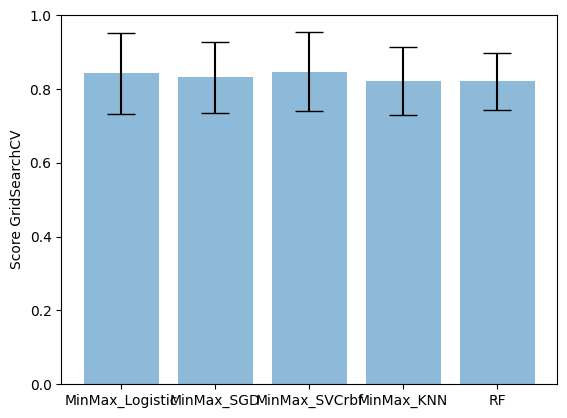

['MinMax_Logistic', 'MinMax_SGD', 'MinMax_SVCrbf', 'MinMax_KNN', 'RF']
[[0.844 0.832 0.847 0.821 0.821]
 [0.11  0.097 0.107 0.092 0.077]]


In [69]:
#recorrer modelos
bars_ = np.zeros((2,len(models)))#arreglo de barras para graficar mejores modelos en promedio con std
for i in range(len(models)):
  ind = models[i].cv_results_['mean_test_score'].argmax()#se determina el mejor score de clasificación
  bars_[0,i] = models[i].cv_results_['mean_test_score'][ind]#guardar score promedio del mejor modelo
  bars_[1,i] = models[i].cv_results_['std_test_score'][ind]#guardar std del mejor modelo

plt.bar(np.arange(len(models)), bars_[0], yerr=bars_[1], align='center', alpha=0.5, ecolor='black', capsize=10)
plt.ylabel('Score GridSearchCV')
plt.xticks(np.arange(len(models)))
plt.gca().set_xticklabels(label_models)
plt.show()

print(label_models)
print(np.round(bars_,3))

Xtest: (55, 7) ytest: (55,)

Evaluando modelo MinMax_Logistic (1/5)
ACC test = 67.27%


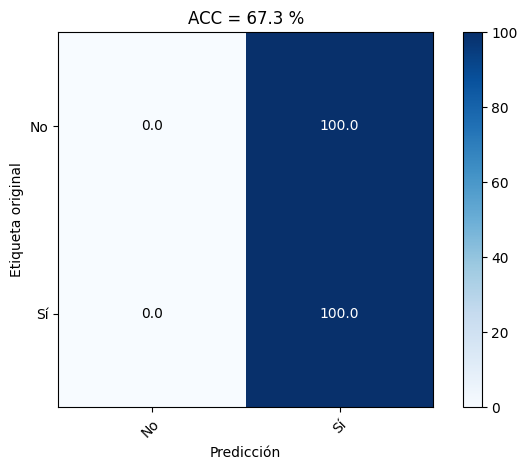

              precision    recall  f1-score   support

          No       0.00      0.00      0.00        18
          Sí       0.67      1.00      0.80        37

    accuracy                           0.67        55
   macro avg       0.34      0.50      0.40        55
weighted avg       0.45      0.67      0.54        55


Evaluando modelo MinMax_SGD (2/5)
ACC test = 80.00%


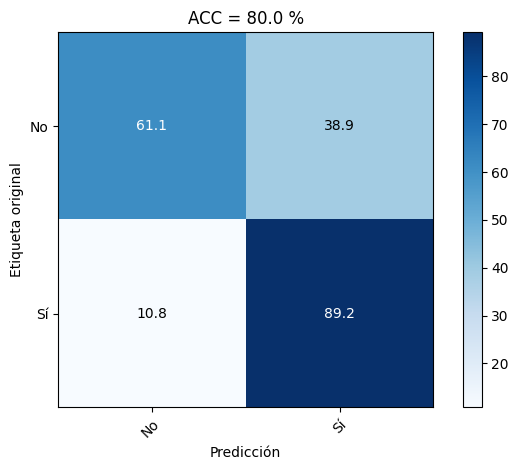

              precision    recall  f1-score   support

          No       0.73      0.61      0.67        18
          Sí       0.82      0.89      0.86        37

    accuracy                           0.80        55
   macro avg       0.78      0.75      0.76        55
weighted avg       0.79      0.80      0.79        55


Evaluando modelo MinMax_SVCrbf (3/5)
ACC test = 67.27%


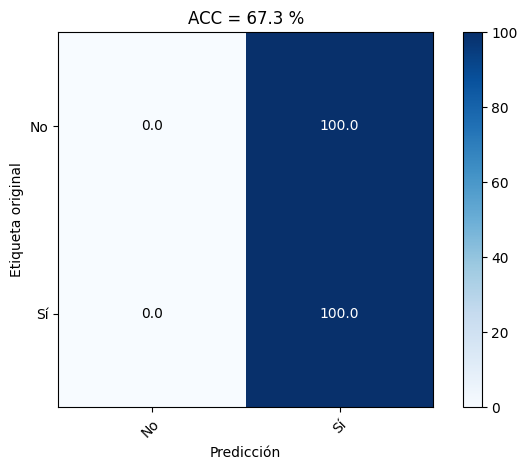

              precision    recall  f1-score   support

          No       0.00      0.00      0.00        18
          Sí       0.67      1.00      0.80        37

    accuracy                           0.67        55
   macro avg       0.34      0.50      0.40        55
weighted avg       0.45      0.67      0.54        55


Evaluando modelo MinMax_KNN (4/5)
ACC test = 72.73%


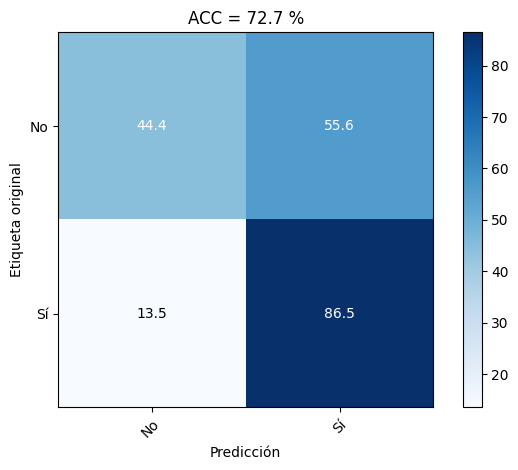

              precision    recall  f1-score   support

          No       0.62      0.44      0.52        18
          Sí       0.76      0.86      0.81        37

    accuracy                           0.73        55
   macro avg       0.69      0.65      0.66        55
weighted avg       0.71      0.73      0.71        55


Evaluando modelo RF (5/5)
ACC test = 74.55%


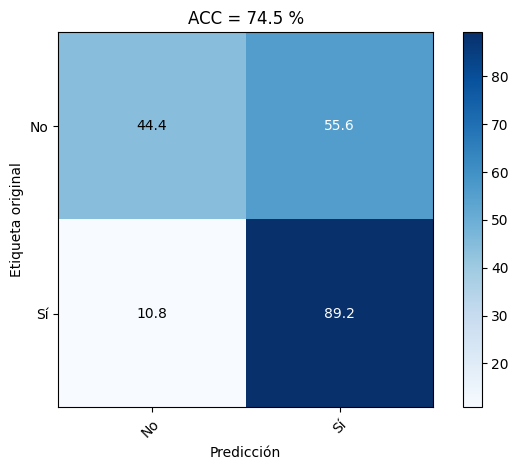

              precision    recall  f1-score   support

          No       0.67      0.44      0.53        18
          Sí       0.77      0.89      0.82        37

    accuracy                           0.75        55
   macro avg       0.72      0.67      0.68        55
weighted avg       0.73      0.75      0.73        55



In [70]:
# %% Evaluar sobre Xtest (Titanic binario) -- versión robusta
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

# IMPORTANTE: 'filename' debe apuntar al mismo usado al guardar (ej: 'results/titanic_models')
my_model_loaded = joblib.load(filename + ".pkl")

# Etiquetas como NumPy array (para permitir indexación por arrays dentro de tu función)
etiquetas_bin = np.array(['No', 'Sí'], dtype=object)  # 0 = No sobrevivió, 1 = Sí sobrevivió

# Asegurar tipos de y reales e índice simple
ytest_arr = np.asarray(ytest).astype(int).ravel()

print("Xtest:", Xtest.shape, "ytest:", ytest_arr.shape)

for i in range(len(my_model_loaded)):
    nombre = label_models[i] if i < len(label_models) else f"Modelo_{i+1}"
    print('\nEvaluando modelo %s (%d/%d)' % (nombre, i+1, len(my_model_loaded)))

    best = my_model_loaded[i].best_estimator_

    # Predicción y tipos consistentes
    ypred = best.predict(Xtest)
    ypred_arr = np.asarray(ypred).astype(int).ravel()

    # Métrica Accuracy
    acc = accuracy_score(ytest_arr, ypred_arr)
    print(f'ACC test = {100*acc:.2f}%')

    # Tu función existente de matriz de confusión:
    # Nota: pasamos y como enteros y 'classes' como np.array para evitar el error de indexación
    plot_confusion_matrix(
        ytest_arr, ypred_arr,
        classes=etiquetas_bin,
        title='ACC = %.1f %%' % (100*acc)
    )
    plt.autoscale()
    plt.show()

    # Reporte de clasificación (con nombres de clase binarios)
    print(classification_report(ytest_arr, ypred_arr, target_names=etiquetas_bin.tolist()))



Evaluando modelo MinMax_Logistic (1/5)

Evaluando modelo MinMax_SGD (2/5)

Evaluando modelo MinMax_SVCrbf (3/5)

Evaluando modelo MinMax_KNN (4/5)

Evaluando modelo RF (5/5)


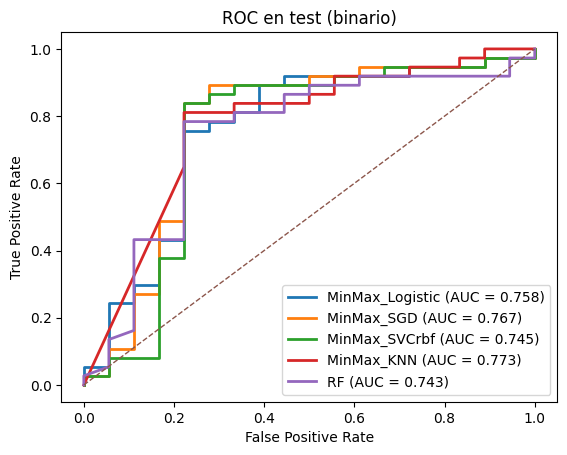


[CV 3/5; 136/144] START cla__class_weight=balanced, cla__max_depth=20, cla__max_features=log2, cla__min_samples_split=5, cla__n_estimators=500
[CV 3/5; 136/144] END cla__class_weight=balanced, cla__max_depth=20, cla__max_features=log2, cla__min_samples_split=5, cla__n_estimators=500;, score=0.856 total time=   1.1s
[CV 2/5; 137/144] START cla__class_weight=balanced, cla__max_depth=20, cla__max_features=log2, cla__min_samples_split=10, cla__n_estimators=200
[CV 2/5; 137/144] END cla__class_weight=balanced, cla__max_depth=20, cla__max_features=log2, cla__min_samples_split=10, cla__n_estimators=200;, score=0.804 total time=   0.4s
[CV 5/5; 137/144] START cla__class_weight=balanced, cla__max_depth=20, cla__max_features=log2, cla__min_samples_split=10, cla__n_estimators=200
[CV 5/5; 137/144] END cla__class_weight=balanced, cla__max_depth=20, cla__max_features=log2, cla__min_samples_split=10, cla__n_estimators=200;, score=0.875 total time=   0.4s
[CV 4/5; 138/144] START cla__class_weight=ba

In [71]:
# %% ROC–AUC binario (Titanic)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Asegura que ytest sea 0/1 y vector 1D
ytest_arr = np.asarray(ytest).astype(int).ravel()

for i in range(len(my_model_loaded)):
    nombre = label_models[i] if i < len(label_models) else f"Modelo_{i+1}"
    print(f'\nEvaluando modelo {nombre} ({i+1}/{len(my_model_loaded)})')

    best = my_model_loaded[i].best_estimator_

    # --- Obtener score continuo para la clase positiva (1) ---
    if hasattr(best, "predict_proba"):
        # Probabilidades -> columna de la clase 1
        y_score = best.predict_proba(Xtest)[:, 1]
    elif hasattr(best, "decision_function"):
        s = best.decision_function(Xtest)
        # Si devuelve (n_samples, 2), tomar la columna de la clase 1
        y_score = s if s.ndim == 1 else s[:, 1]
    else:
        raise ValueError(f"{nombre} no tiene predict_proba ni decision_function")

    # --- Curva ROC y AUC ---
    fpr, tpr, _ = roc_curve(ytest_arr, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {roc_auc:.3f})')

# Diagonal azar y detalles del plot
plt.plot([0, 1], [0, 1], lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC en test (binario)')
plt.legend(loc='lower right')
plt.show()
